In [65]:
%%bigquery

CREATE OR REPLACE TABLE mystical-rhino-455605-n8.mvp_conjunto_dados.filmes_populares_2004_2024 AS
SELECT *
FROM (
  SELECT
    b.tconst,
    b.primary_Title,
    b.start_Year,
    b.genres,
    r.average_Rating,
    r.num_Votes
  FROM
    imdb.title_basics b
  JOIN
    imdb.title_ratings r
  ON
    b.tconst = r.tconst
  WHERE
    b.title_Type = 'movie'
    AND b.is_Adult = 0
    AND b.start_Year BETWEEN 2004 AND 2024
    AND r.num_Votes > 250000
  ORDER BY
    r.average_Rating DESC,
    r.num_Votes DESC
  LIMIT 50
);


Query is running:   0%|          |

""


In [66]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client()

query = """
SELECT primary_Title
FROM `mystical-rhino-455605-n8.mvp_conjunto_dados.filmes_populares_2004_2024`
ORDER BY num_Votes DESC
LIMIT 50"""


df_titles = client.query(query).to_dataframe()
titles = df_titles['primary_Title'].dropna().unique().tolist()


In [67]:
from google.cloud import bigquery, storage
import pandas as pd
from io import StringIO


# Conecta com BigQuery
bq_client = bigquery.Client()


# Consulta filmes populares
query = """
SELECT primary_Title, start_Year, genres, average_Rating, num_Votes
FROM `mystical-rhino-455605-n8.mvp_conjunto_dados.filmes_populares_2004_2024`
"""
df_filmes = bq_client.query(query).to_dataframe()


# Conecta com GCS
bucket_name = "mvp_files"
prefix = "mvp_trends/"
storage_client = storage.Client()
bucket = storage_client.get_bucket(bucket_name)
blobs = bucket.list_blobs(prefix=prefix)
arquivos = [blob.name for blob in blobs if blob.name.endswith(".csv")]


# Carrega arquivos
coluna_mes = None
colunas_filmes = []
nomes_colunas = []


for blob_name in sorted(arquivos):
    blob = bucket.blob(blob_name)


    # Tenta ler o arquivo com múltiplas codificações
    conteudo_bytes = blob.download_as_bytes()
    conteudo = None
    for encoding in ['utf-8', 'latin1', 'windows-1252']:
        try:
            conteudo = conteudo_bytes.decode(encoding)
            break
        except:
            continue
    if conteudo is None:
        print(f"Erro ao decodificar {blob_name}")
        continue


    try:
        df = pd.read_csv(StringIO(conteudo), skiprows=1)
        nome_coluna = df.columns[1]
        nome_coluna_limpo = nome_coluna.replace(": (Mundo)", "").replace("(Mundo)", "").strip()
        df.columns = ["Mês", nome_coluna_limpo]


        if coluna_mes is None:
            coluna_mes = df["Mês"]
        colunas_filmes.append(df[nome_coluna_limpo])
        nomes_colunas.append(nome_coluna_limpo)
    except Exception as e:
        print(f"Erro ao processar {blob_name}: {e}")


# Junta tudo num único DataFrame
df_trends = pd.concat([coluna_mes] + colunas_filmes, axis=1)
df_trends = df_trends.sort_values("Mês").reset_index(drop=True)
df_trends.columns = ["Mês"] + nomes_colunas


# Cruzamento com os filmes
titulos_em_comum = set(df_filmes["primary_Title"]) & set(df_trends.columns[1:])
df_filmes_filtrados = df_filmes[df_filmes["primary_Title"].isin(titulos_em_comum)]
df_trends_filtrados = df_trends[["Mês"] + list(titulos_em_comum)]


# Exporta CSVs
df_filmes_filtrados.to_csv("filmes_filtrados.csv", index=False)
df_trends_filtrados.to_csv("trends_filtrados.csv", index=False)


print(f"{len(titulos_em_comum)} filmes encontrados em comum.")
print("Arquivos salvos: filmes_filtrados.csv e trends_filtrados.csv")

50 filmes encontrados em comum.
Arquivos salvos: filmes_filtrados.csv e trends_filtrados.csv


In [74]:
import pandas as pd
import matplotlib.pyplot as plt


# Carrega os CSVs
df_trends = pd.read_csv("trends_filtrados.csv")
df_filmes = pd.read_csv("filmes_filtrados.csv")


# Converte "<1" para 0.5 e transforma em float
for col in df_trends.columns[1:]:
    df_trends[col] = df_trends[col].replace("<1", 0.5).astype(float)


# Converte coluna de mês
df_trends["Mês"] = pd.to_datetime(df_trends["Mês"])


# Calcula média de interesse por filme
medias_trends = df_trends.drop("Mês", axis=1).mean().reset_index()
medias_trends.columns = ["primary_Title", "media_interesse"]


# Junta com os dados do IMDb
df_analise = pd.merge(df_filmes, medias_trends, on="primary_Title")


# Correlação entre média de interesse e nota
correlacao = df_analise["media_interesse"].corr(df_analise["average_Rating"])
print(f"Correlação entre interesse médio e nota IMDb: {correlacao:.2f}")


# Top 10 filmes por interesse
top_interesse = df_analise.sort_values("media_interesse", ascending=False).head(10)
print("\nTop 10 por interesse médio:")
print(top_interesse[["primary_Title", "media_interesse", "average_Rating", "num_Votes"]])


# Interesse médio por gênero principal
df_analise["genero_principal"] = df_analise["genres"].apply(lambda x: x.split(",")[0] if pd.notnull(x) else None)
genero_media = df_analise.groupby("genero_principal")["media_interesse"].mean().sort_values(ascending=False)
print("\nInteresse médio por gênero:")
print(genero_media)
























Correlação entre interesse médio e nota IMDb: -0.14

Top 10 por interesse médio:
                            primary_Title  media_interesse  average_Rating  \
40                   Howl's Moving Castle        20.519531             8.2   
48                            Ratatouille        18.998047             8.1   
24  Eternal Sunshine of the Spotless Mind        13.277344             8.3   
4                            The Prestige        11.968750             8.5   
23                                     Up        11.398438             8.3   
27                               The Hunt        10.882812             8.3   
8                        The Intouchables        10.085938             8.5   
34                              Prisoners         9.417969             8.2   
37                        Pan's Labyrinth         9.353516             8.2   
21                             Your Name.         8.535156             8.4   

    num_Votes  
40     480182  
48     880245  
24    113248

In [75]:
# Ordena pelos mais bem avaliados com pouco interesse
curiosos_2 = df_analise[df_analise["media_interesse"] < 5].sort_values("average_Rating", ascending=False).head(10)
print("\nFilmes com alta nota, mas pouco buscados:")
print(curiosos_2[["primary_Title", "average_Rating", "media_interesse", "num_Votes"]])



Filmes com alta nota, mas pouco buscados:
                          primary_Title  average_Rating  media_interesse  \
0                       The Dark Knight             9.0         4.210938   
1                             Inception             8.8         4.333984   
2                          Interstellar             8.7         3.484375   
3                      Django Unchained             8.5         3.869141   
7                              Parasite             8.5         2.031250   
9                        Dune: Part Two             8.5         1.117188   
10                    The Kashmir Files             8.5         0.619141   
11  Spider-Man: Across the Spider-Verse             8.5         1.152344   
12                The Dark Knight Rises             8.4         2.638672   
14                    Avengers: Endgame             8.4         1.970703   

    num_Votes  
0     3007338  
1     2671607  
2     2328469  
3     1782298  
7     1053627  
9      620817  
10     5

In [76]:
correlacao_votos = df_analise["media_interesse"].corr(df_analise["num_Votes"])
print(f"\nCorrelação entre interesse médio e número de votos no IMDb: {correlacao_votos:.2f}")



Correlação entre interesse médio e número de votos no IMDb: -0.18


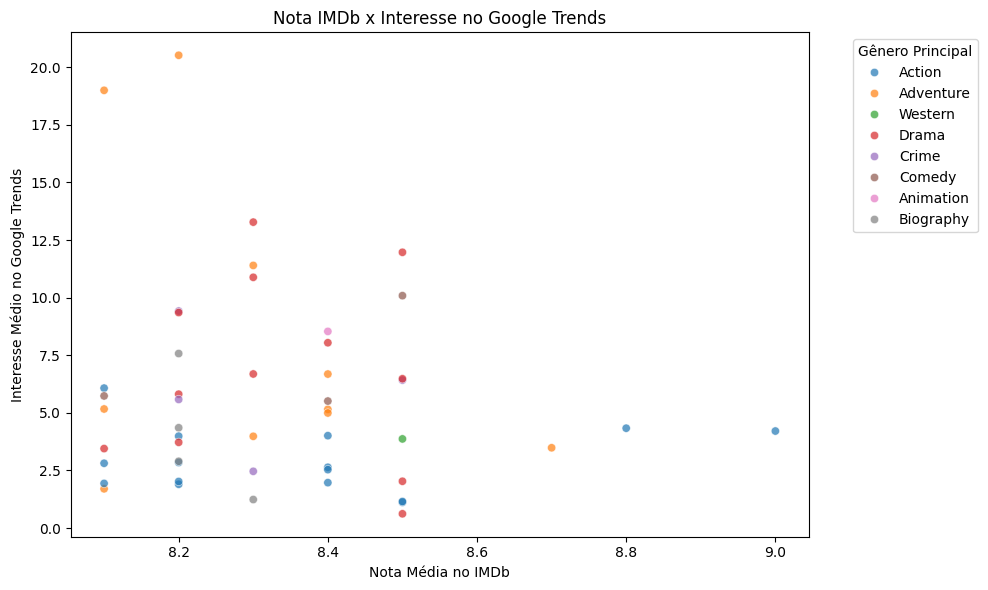

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_analise, x="average_Rating", y="media_interesse", hue="genero_principal", alpha=0.7)
plt.title("Nota IMDb x Interesse no Google Trends")
plt.xlabel("Nota Média no IMDb")
plt.ylabel("Interesse Médio no Google Trends")
plt.legend(title="Gênero Principal", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


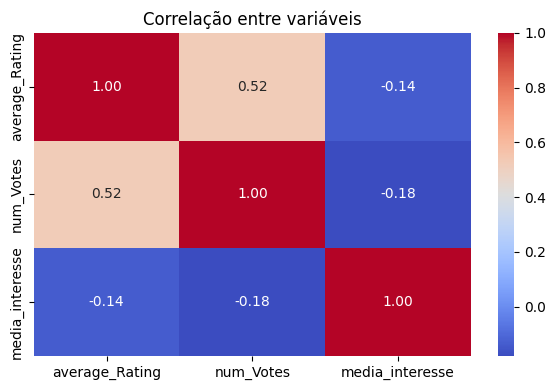

In [78]:
plt.figure(figsize=(6, 4))
correlacoes = df_analise[["average_Rating", "num_Votes", "media_interesse"]].corr()
sns.heatmap(correlacoes, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlação entre variáveis")
plt.tight_layout()
plt.show()


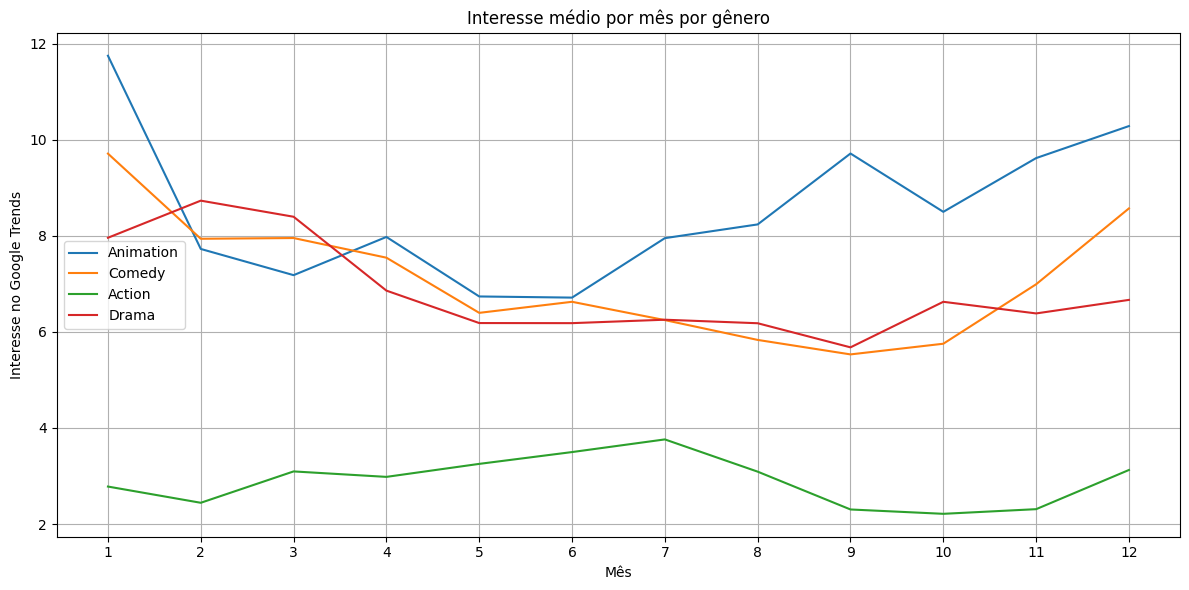

In [80]:
import pandas as pd
import matplotlib.pyplot as plt


# 1. Adiciona a coluna com o número do mês
df_trends["mês_numérico"] = pd.to_datetime(df_trends["Mês"]).dt.month


# 2. Extrai o gênero principal
df_filmes["genero_principal"] = df_filmes["genres"].apply(lambda x: x.split(",")[0] if pd.notna(x) else "desconhecido")


# 3. Junta os títulos reais com os nomes das colunas do df_trends
colunas_trends = set(df_trends.columns) - {"Mês", "mês_numérico"}
df_analise = df_filmes[df_filmes["primary_Title"].isin(colunas_trends)]


# 4. Calcula interesse médio por mês para cada gênero
media_genero_mes = {}
for genero in df_analise["genero_principal"].unique():
    filmes_genero = df_analise[df_analise["genero_principal"] == genero]["primary_Title"]
    cols = [col for col in df_trends.columns if col in filmes_genero.values]
    if cols:
        media = df_trends[["mês_numérico"] + cols].groupby("mês_numérico").mean().mean(axis=1)
        media_genero_mes[genero] = media


# 5. Plota os principais gêneros
plt.figure(figsize=(12,6))
generos_plotar = ["Horror", "Animation", "Comedy", "Action", "Drama"]
for genero in generos_plotar:
    if genero in media_genero_mes:
        media_genero_mes[genero].plot(label=genero)


plt.legend()
plt.title("Interesse médio por mês por gênero")
plt.xlabel("Mês")
plt.ylabel("Interesse no Google Trends")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()
